# Simple Linear Regression 

### Problem Statement: Predict Height from 1 freatures (weight)

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


## 1. Exploratory Data Analysis

In [3]:
# Shape of the Dataset
row, col = df.shape
print(f"The dataset has {row} rows and {col} columns.")

The dataset has 23 rows and 2 columns.


In [4]:
# What columns the dataset has and what's their type?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [5]:
# Is any data missing?
missing_count = df.isnull().sum()
missing_count

Weight    0
Height    0
dtype: int64

In [6]:
# Is there any duplicated value?
duplicate_count = df.duplicated().sum()
duplicate_count

1

In [7]:
# Summary Statistics 
df.describe().round(2)

,Weight,Height
count,23.00,23.00
mean,73.83,158.39
std,17.87,19.51
min,45.00,120.00
25%,59.00,142.50
50%,78.00,162.00
75%,86.00,175.00
max,105.00,183.00


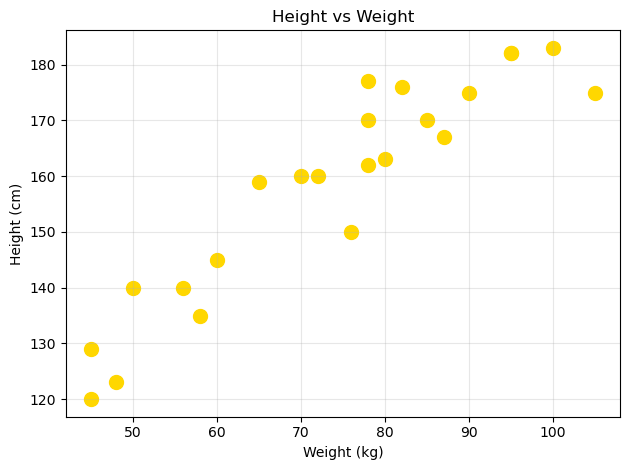

In [8]:
# Visualize the data
plt.scatter(x=df['Weight'], y=df['Height'], s=100, c='gold')
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')
plt.title('Height vs Weight')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Check Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


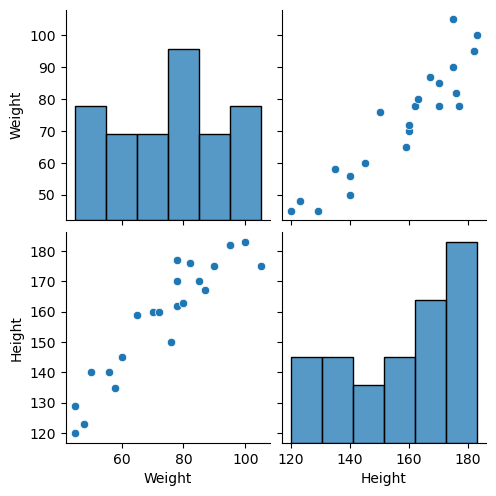

In [10]:
# Pairplot reveals how different features correlate and how individual values are distributed
sns.pairplot(df)

## 2. Feature Engineering

In [11]:
# Separate Independent and dependent features
X = df[['Weight']]
y = df['Height']

In [12]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [13]:
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (17, 1)
Testing set: (6, 1)


In [14]:
# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Weight (mean): {X_train.mean():.1f}, (std): {X_train.std():.1f}")
print(f"Height (mean): {X_test.mean():.1f}, (std): {X_test.std():.1f}")

Weight (mean): 0.0, (std): 1.0
Height (mean): 0.3, (std): 1.2


## 3. Train the Model

In [15]:
# Apply Simple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficient: [17.2982057]
Intercept: 156.47058823529412


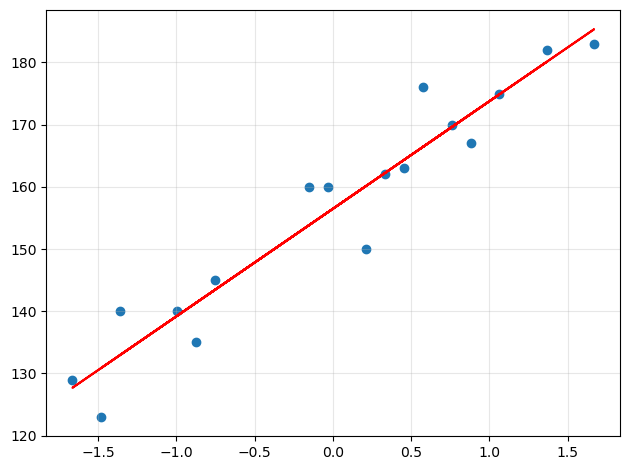

In [16]:
# Plot the best fit line on the training data
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), c='r')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Prediction of Test Data

In [17]:
y_pred = model.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [18]:
y_test

15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64

In [19]:
# Cross-Validation
validation_score = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=3)
np.mean(validation_score)

-40.10612150552165

## 5. Perfomance Metrics 

In [20]:
# Calculate MSE, RMSE, MAE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 114.8407
Root Mean Squared Error: 10.7164
Mean Absolute Error: 9.6651


In [21]:
# Calculate R Square & Adjusted R Square
r2 = r2_score(y_test, y_pred)
print(f"R Square: {r2:.4f}")

adjusted_r2 = 1 - (1-r2)*(len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R Square: {adjusted_r2:.4f}")

R Square: 0.7361
Adjusted R Square: 0.6701
